<a href="https://colab.research.google.com/github/mikakia/AdvanceML_Final_Project/blob/main/attention_unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Functions

In [2]:
# for downdsamplig
def double_conv(input_c, output_c):
  conv = nn.Sequential(
                                 nn.Conv2d(in_channels=input_c,out_channels=output_c, kernel_size=3,padding='same'),      # (2)
                                 nn.ReLU(inplace=True) ,                                                                  # (3)
                                 nn.Conv2d(in_channels=output_c,out_channels=output_c, kernel_size=3,padding='same'),     # second unpadded convolution
                                 nn.ReLU(inplace=True)  )
  return conv



# Plot
def plot(input,output):



  fig, axes = plt.subplots(1, 3, figsize=(15, 5))

  axes[0].imshow(image[0, 0].detach().numpy(), cmap='gray')
  axes[0].set_title('Input Image')

  axes[1].imshow(output[0, 0].detach().numpy(), cmap='gray')
  axes[1].set_title('Class 0')

  axes[2].imshow(output[0, 1].detach().numpy(), cmap='gray')
  axes[2].set_title('Class 1')

  plt.savefig('classes.png', dpi=150, bbox_inches='tight')
  plt.show()


  # Attention
  def attention(x, gating, inter_shape, layers_dict):
    # x, comes from skip connections
    # g, gating signal comes from the next lowest layer of the network
    shape_x = x.shape

    # making x the same shape as the gating signal
    theta_x = layers_dict['theta_x'](x)

    phi_g = layers_dict['phi_g'](gating)

    # concatenation (element-wise addition)
    concat_xg = phi_g + theta_x

    # attention gate

    # activation function
    act_xg = F.relu(concat_xg)

    psi = layers_dict['psi'](act_xg)

    sigmoid_xg = torch.sigmoid(psi)
    shape_sigmoid = sigmoid_xg.shape

    # upsampling
    upsample_psi = F.interpolate(sigmoid_xg,
                                 size=(shape_x[2], shape_x[3]),
                                 mode='bilinear',
                                 align_corners=True)

    y = upsample_psi * x

    result = layers_dict['result_conv'](y)
    result_bn = layers_dict['bn'](result)

    return result_bn

# Defining UNet Class

Building a UNet based on the orginal UNet paper.

*   The contracting part (left side) follows the typical architecture of a convulotinal neural network.
*   It consists of the repeated application of two 3x3 unpadded convolutions(2), each followed by ReLU (3)(4)and a 2x2 max pooling operation with stride 2 for downsampling(1). At each downsampling step we double the number of feature channels (5).
*   Upsampling and transpose convolutions (6)
*   Upsampling of the feature map followed by a 2x2 convolution that halves the
number of feature channels, a concatenation with the correspondingly cropped
feature map from the contracting path, and two 3x3 convolutions, each fol-
lowed by a ReLU.






The concatenation  (skip connections) combines spatial info from the downsampling path with the up-sampling path to retain good spatial info

Apply soft attention (add weights to pixels based on the relevance) at the skip connections will actively surpass activations at the irrelavant regions. Add attnetions at the skip connections.

## With Attention

In [5]:
class AttentionBlock(nn.Module):
    def __init__(self, x_channels, g_channels, inter_channels):
        super(AttentionBlock, self).__init__()

        self.theta_x = nn.Conv2d(x_channels, inter_channels, kernel_size=1, stride=2)
        self.phi_g   = nn.Conv2d(g_channels,  inter_channels, kernel_size=1)
        self.psi     = nn.Conv2d(inter_channels, 1, kernel_size=1)
        self.result_conv = nn.Conv2d(x_channels, x_channels, kernel_size=1)
        self.bn      = nn.BatchNorm2d(x_channels)

    def forward(self, x, gating):
        theta_x    = self.theta_x(x)
        phi_g      = self.phi_g(gating)
        concat_xg  = phi_g + theta_x
        act_xg     = F.relu(concat_xg)
        psi        = self.psi(act_xg)
        sigmoid_xg = torch.sigmoid(psi)

        upsample_psi = F.interpolate(sigmoid_xg,
                                     size=(x.shape[2], x.shape[3]),
                                     mode='bilinear',
                                     align_corners=True)
        y         = upsample_psi * x
        result    = self.result_conv(y)
        result_bn = self.bn(result)
        return result_bn


class UNet_Attention(nn.Module):

  def __init__(self):
    super(UNet_Attention, self).__init__()                                   # initiliazion for nn.Module
    self.max_pool_2x2 = nn.MaxPool2d(kernel_size=2,stride=2)       # (1)

    # first part Downsampling (5)
    self.down_conv_1 = double_conv(1,64)
    self.down_conv_2 = double_conv(64,128)
    self.down_conv_3 = double_conv(128,256)
    self.down_conv_4 = double_conv(256,512)
    self.down_conv_5 = double_conv(512,1024)

    #  second part Upsampling (6) transpose convolution

    # First
    self.up_trans_1 = nn.ConvTranspose2d(in_channels=1024,          # input channels from the last down_conv5 and
                                        out_channels=512,           # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_1 = double_conv(1024,512)


    # Second
    self.up_trans_2 = nn.ConvTranspose2d(in_channels=512,          # input channels from the last down_conv5 and
                                        out_channels=256,          # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_2 = double_conv(512,256)


    # Third
    self.up_trans_3 = nn.ConvTranspose2d(in_channels=256,           # input channels from the last down_conv5 and
                                        out_channels=128,           # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_3= double_conv(256,128)

    # Fourth
    self.up_trans_4 = nn.ConvTranspose2d(in_channels=128,          # input channels from the last down_conv5 and
                                        out_channels=64,           # output channels from the output of down_conv4 which is passed to the decoder
                                       kernel_size=2,stride=2)

    self.up_conv_4 = double_conv(128,64)

    # Attention blocks (x_channels, g_channels, inter_channels)
    self.attn_1 = AttentionBlock(x_channels=512,  g_channels=1024, inter_channels=256)
    self.attn_2 = AttentionBlock(x_channels=256,  g_channels=512,  inter_channels=128)
    self.attn_3 = AttentionBlock(x_channels=128,  g_channels=256,  inter_channels=64)
    self.attn_4 = AttentionBlock(x_channels=64,   g_channels=128,  inter_channels=32)

    # Output layer
    self.output = nn.Conv2d(in_channels=64,out_channels=2, kernel_size=1)  # 2d convolition with kernel size of 1

  def forward(self,image):

    # batch size, channels, height and width
    print("\n =============ENCODER===============\n")
    # encoder layers
    x1 = self.down_conv_1(image) # output passed to the decoder
    print("First encoder layer:", x1.size())
    x2 = self.max_pool_2x2(x1)
    x3 = self.down_conv_2(x2)    # output passed to the decoder
    x4 = self.max_pool_2x2(x3)
    x5 = self.down_conv_3(x4)    # output passed to the decoder
    x6 = self.max_pool_2x2(x5)
    x7 = self.down_conv_4(x6)    # output passed to the decoder
    print("4th encoder layer size x7", x7.size())
    x8 = self.max_pool_2x2(x7)
    x9 = self.down_conv_5(x8)
    print("Last encoder layer x9:",x9.size())

    # decoder layers

    print("\n =============DECODER===============\n")
    # First
    # ----- attention first layer --------
    # x9 is the gating signal
    # x7 is the skip connection
    x7_att = self.attn_1(x7, x9)
    x = self.up_trans_1(x9)                       # x should be concatened with x7 to create the skip connections in Unet
    print("First decoder layer x: ",x.size())
    x = self.up_conv_1(torch.cat([x,x7_att],1))
    print(x.size())

    # Second
    # ----- attention second layer --------
    # x is the gating signal
    # x5 is the skip connection
    x5_att = self.attn_2(x5, x)
    x = self.up_trans_2(x)                       # x should be concatened with x5 to create the skip connections in Unet
    print("Second decoder layer x: ",x.size())
    x = self.up_conv_2(torch.cat([x,x5_att],1))
    print(x.size())

    # Third
    # ----- attention third layer --------
    # x is the gating signal
    # x3 is the skip connection
    x3_att = self.attn_3(x3, x)
    x = self.up_trans_3(x)                       # x should be concatened with x3 to create the skip connections in Unet
    print("Third decoder layer x: ",x.size())
    x = self.up_conv_3(torch.cat([x,x3_att],1))
    print(x.size())

    # Fourth
    # ----- attention fourth layer --------
    # x is the gating signal
    # x1 is the skip connection
    x1_att = self.attn_4(x1, x)
    x = self.up_trans_4(x)                       # x should be concatened with x1 to create the skip connections in Unet
    print("Fourth decoder layer x: ",x.size())
    x = self.up_conv_4(torch.cat([x,x1_att],1))
    print(x.size())

    # Output
    out = self.output(x)
    print("Output size: ",out.size())

    return out

## Without Attention

In [19]:
class UNet(nn.Module):

  def __init__(self):
    super(UNet, self).__init__()                                   # initiliazion for nn.Module
    self.max_pool_2x2 = nn.MaxPool2d(kernel_size=2,stride=2)       # (1)

    # first part Downsampling (5)
    self.down_conv_1 = double_conv(1,64)
    self.down_conv_2 = double_conv(64,128)
    self.down_conv_3 = double_conv(128,256)
    self.down_conv_4 = double_conv(256,512)
    self.down_conv_5 = double_conv(512,1024)

    #  second part Upsampling (6) transpose convolution

    # First
    self.up_trans_1 = nn.ConvTranspose2d(in_channels=1024,          # input channels from the last down_conv5 and
                                        out_channels=512,           # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_1 = double_conv(1024,512)


    # Second
    self.up_trans_2 = nn.ConvTranspose2d(in_channels=512,          # input channels from the last down_conv5 and
                                        out_channels=256,          # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_2 = double_conv(512,256)


    # Third
    self.up_trans_3 = nn.ConvTranspose2d(in_channels=256,           # input channels from the last down_conv5 and
                                        out_channels=128,           # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_3= double_conv(256,128)

    # Fourth
    self.up_trans_4 = nn.ConvTranspose2d(in_channels=128,          # input channels from the last down_conv5 and
                                        out_channels=64,           # output channels from the output of down_conv4 which is passed to the decoder
                                       kernel_size=2,stride=2)

    self.up_conv_4 = double_conv(128,64)

    # Output layer
    self.output = nn.Conv2d(in_channels=64,out_channels=2, kernel_size=1)  # 2d convolition with kernel size of 1

  def forward(self,image):

    # batch size, channels, height and width
    print("\n =============ENCODER===============\n")
    # encoder layers
    x1 = self.down_conv_1(image) # output passed to the decoder
    print("First encoder layer:", x1.size())
    x2 = self.max_pool_2x2(x1)
    x3 = self.down_conv_2(x2)    # output passed to the decoder
    x4 = self.max_pool_2x2(x3)
    x5 = self.down_conv_3(x4)    # output passed to the decoder
    x6 = self.max_pool_2x2(x5)
    x7 = self.down_conv_4(x6)    # output passed to the decoder
    print("4th encoder layer size x7", x7.size())
    x8 = self.max_pool_2x2(x7)
    x9 = self.down_conv_5(x8)
    print("Last encoder layer x9:",x9.size())

    # decoder layers

    print("\n =============DECODER===============\n")
    # First
    x = self.up_trans_1(x9)                       # x should be concatened with x7 to create the skip connections in Unet
    print("First decoder layer x: ",x.size())
    x = self.up_conv_1(torch.cat([x,x7],1))
    print(x.size())

    # ----- attention first layer --------
    # x9 is the gating signal
    # x is the result of the skip connection

    # Second

    x = self.up_trans_2(x)                       # x should be concatened with x5 to create the skip connections in Unet
    print("Second decoder layer x: ",x.size())
    x = self.up_conv_2(torch.cat([x,x5],1))
    print(x.size())


    # Third

    x = self.up_trans_3(x)                       # x should be concatened with x3 to create the skip connections in Unet
    print("Third decoder layer x: ",x.size())
    x = self.up_conv_3(torch.cat([x,x3],1))
    print(x.size())




    # Fourth

    x = self.up_trans_4(x)                       # x should be concatened with x1 to create the skip connections in Unet
    print("Fourth decoder layer x: ",x.size())
    x = self.up_conv_4(torch.cat([x,x1],1))
    print(x.size())

    # Output
    out = self.output(x)
    print("Output size: ",out.size())

    return out

# Run

In [6]:
image = torch.rand((1,1,256,256)) # batch size=1, channels=1, height=572 and width=572 following the original paper
model = UNet_Attention()
output = model(image)
print("Model:",output)




 =============ENCODER===============

First encoder layer: torch.Size([1, 64, 256, 256])
4th encoder layer size x7 torch.Size([1, 512, 32, 32])
Last encoder layer x9: torch.Size([1, 1024, 16, 16])

 =============DECODER===============

First decoder layer x:  torch.Size([1, 512, 32, 32])
torch.Size([1, 512, 32, 32])
Second decoder layer x:  torch.Size([1, 256, 64, 64])
torch.Size([1, 256, 64, 64])
Third decoder layer x:  torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
Fourth decoder layer x:  torch.Size([1, 64, 256, 256])
torch.Size([1, 64, 256, 256])
Output size:  torch.Size([1, 2, 256, 256])
Model: tensor([[[[-0.0350, -0.1126, -0.1648,  ..., -0.1219, -0.1030, -0.0940],
          [-0.0269, -0.0989, -0.0769,  ..., -0.0009, -0.0094, -0.0503],
          [-0.0588, -0.0343, -0.0910,  ..., -0.1077, -0.1312, -0.0593],
          ...,
          [-0.1322, -0.0419, -0.1241,  ..., -0.0086, -0.0994, -0.0313],
          [ 0.0232, -0.0367, -0.0061,  ..., -0.0232, -0.0289, -0.0970],
  

In [24]:
print(model)

UNet(
  (max_pool_2x2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down_conv_1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU(inplace=True)
  )
  (down_conv_2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU(inplace=True)
  )
  (down_conv_3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU(inplace=True)
  )
  (down_conv_4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU(inplace=True)
    (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1

# Plot

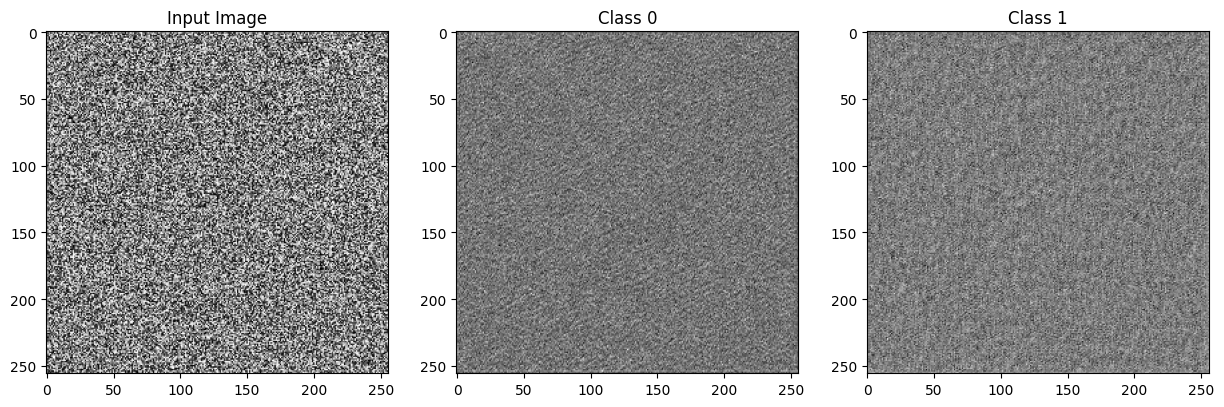

In [17]:
plot(image,output)

In [18]:
print(output[:, 0, :, :].mean())  # class 0 mean
print(output[:, 1, :, :].mean())  # class 1 mean

tensor(0.0878, grad_fn=<MeanBackward0>)
tensor(0.0793, grad_fn=<MeanBackward0>)
